<a href="https://colab.research.google.com/github/fehimecapar/Data-Science-For-Decision-Support/blob/main/Assignment_4_Mixed_to_Reduced_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ödev 4 — Kümeleme ve Boyut Azaltma (Güncellenmiş)
**Hazırlandı:** 2026-02-04

Bu sürüm, öğretim görevlisinin uyarıları doğrultusunda güncellendi:

- **1.1:** Karışık veri (kategorik + sayısal) için **k‑Prototypes** kullanıldı.
- **Boyut azaltma sonrası (FAMD ile %85+ inertia):** **k‑Means**, **Hiyerarşik (Ward)**, **DBSCAN**, **HDBSCAN** uygulandı.
- **Görselleştirme (azaltılmış uzay):** Yalnızca sayısal bileşenler olduğundan **PCA (2B/3B)** ve **t‑SNE (2B/3B)** ile gösterimler yapıldı.
- **İstenen karşılaştırmalar:** KPrototypes (önce) ↔ KMeans (sonra), Ward (önce) ↔ Ward (sonra), DBSCAN (önce) ↔ DBSCAN (sonra), HDBSCAN (önce) ↔ HDBSCAN (sonra).


In [1]:
# === Kurulum (Colab için) ===
import sys, subprocess, importlib
def pip_install(pkg):
    try:
        importlib.import_module(pkg.split('==')[0].split('[')[0])
    except Exception:
        print(f'Installing {pkg} ...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
        print(f'Installed {pkg}')

for p in ['plotly==5.24.1','kaleido','scikit-learn','scipy','pandas','numpy','matplotlib','seaborn','hdbscan','kmodes','prince','gower']:
    pip_install(p)


Installing kaleido ...
Installed kaleido
Installing scikit-learn ...
Installed scikit-learn


/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


Installing kmodes ...
Installed kmodes
Installing prince ...
Installed prince
Installing gower ...
Installed gower


In [2]:
# === Kütüphaneler ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, fowlkes_mallows_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics.cluster import contingency_matrix
import warnings
warnings.filterwarnings('ignore')

# Opsiyonel paketler
try:
    import hdbscan
except Exception:
    hdbscan = None
try:
    from kmodes.kprototypes import KPrototypes
except Exception:
    KPrototypes = None
try:
    import prince
except Exception:
    prince = None
try:
    import gower
except Exception:
    gower = None

sns.set(style='whitegrid')


In [3]:
# === Veri Yükleme ===
try:
    from google.colab import files
    uploaded = files.upload()
    file_name = list(uploaded.keys())[0]
except Exception:
    file_name = '21_Fish_market_regression.xlsx'

df = pd.read_excel(file_name, engine='openpyxl')
print(df.shape)
display(df.head())
display(df.describe(include='all'))
print('Columns:', df.columns.tolist())


Saving 21_Fish_market_regression.xlsx to 21_Fish_market_regression (1).xlsx
(159, 7)


,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


,Species,Weight,Length1,Length2,Length3,Height,Width
count,159,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
unique,7,NaN,NaN,NaN,NaN,NaN,NaN
top,Perch,NaN,NaN,NaN,NaN,NaN,NaN
freq,56,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,398.326415,26.247170,28.415723,31.227044,8.970994,4.417486
std,NaN,357.978317,9.996441,10.716328,11.610246,4.286208,1.685804
min,NaN,0.000000,7.500000,8.400000,8.800000,1.728400,1.047600
25%,NaN,120.000000,19.050000,21.000000,23.150000,5.944800,3.385650
50%,NaN,273.000000,25.200000,27.300000,29.400000,7.786000,4.248500
75%,NaN,650.000000,32.700000,35.500000,39.650000,12.365900,5.584500


Columns: ['Species', 'Weight', 'Length1', 'Length2', 'Length3', 'Height', 'Width']


In [5]:
target_col = 'Weight'
cat_cols = ['Species']
num_cols = [c for c in df.columns if c not in cat_cols + [target_col]]

# X (features), Y (regression) ve sınıf etiketleri (dış metrikler için)
X_mix = df[cat_cols + num_cols].copy()
y_reg = df[target_col].values
limit_value = float(np.median(y_reg))
y_cls = np.where(y_reg < limit_value, 1, 2)
print(f'limit_value (Weight median): {limit_value:.3f}')

num_transform = Pipeline([('imp', SimpleImputer(strategy='mean')), ('sc', StandardScaler())])
X_num_scaled = num_transform.fit_transform(df[num_cols])

# One-hot + numerical (Ward and some metrics)
cat_transform = Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
pre_full = ColumnTransformer([('num', num_transform, num_cols), ('cat', cat_transform, cat_cols)])
X_full = pre_full.fit_transform(X_mix)

# Gower distance (mixed dataset)
def gower_distance_manual(df_mix, cat_cols, num_cols):
    A = df_mix.copy()
    A_cat = A[cat_cols].astype('category')
    A_num = A[num_cols].astype(float).copy()
    mins = A_num.min(axis=0); maxs = A_num.max(axis=0)
    ranges = (maxs - mins).replace(0, 1.0)
    A_num_norm = (A_num - mins) / ranges
    Xn = A_num_norm.values; N = Xn.shape[0]
    dists_num = np.zeros((N,N))
    if Xn.shape[1] > 0:
        for i in range(N):
            dists_num[i] = np.abs(Xn[i] - Xn).mean(axis=1)
    dists_cat = np.zeros((N,N))
    if len(cat_cols) > 0:
        Xc = np.column_stack([A_cat[c].cat.codes.values for c in cat_cols])
        for i in range(N):
            dists_cat[i] = (Xc[i] != Xc).mean(axis=1)
    if (Xn.shape[1] > 0) and (len(cat_cols)>0):
        return 0.5*dists_num + 0.5*dists_cat
    return dists_num if Xn.shape[1]>0 else dists_cat

def compute_gower_matrix(df_in, cat_cols, num_cols):
    try:
        import gower as _g
        return _g.gower_matrix(df_in[cat_cols + num_cols])
    except Exception:
        return gower_distance_manual(df_in[cat_cols + num_cols], cat_cols, num_cols)


limit_value (Weight median): 273.000


## 1.1 k‑Prototypes Clustering (mixed dataset)

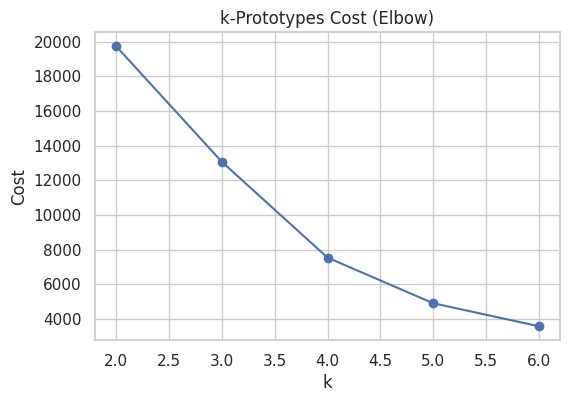

Best k = 6


,Species,Length1,Length2,Length3,Height,Width,cluster_kprototypes
0,Bream,23.2,25.4,30.0,11.5200,4.0200,2
1,Bream,24.0,26.3,31.2,12.4800,4.3056,2
2,Bream,23.9,26.5,31.1,12.3778,4.6961,2
3,Bream,26.3,29.0,33.5,12.7300,4.4555,4
4,Bream,26.5,29.0,34.0,12.4440,5.1340,4


In [7]:
# === 1.1 k‑Prototypes ===
assert KPrototypes is not None, 'kmodes/kprototypes paketi eksik; kurulum h cresini çal ¾t¹r¹n.'
# Data (Features): Species (categorical) + numerical columns (except for Weight )
X_kp = df[cat_cols + num_cols].copy()
cat_idx = [X_kp.columns.get_loc(c) for c in cat_cols]

#  cost for k (elbow)
Ks = list(range(2,9))
costs = []
for k in Ks:
    try:
        kp = KPrototypes(n_clusters=k, init='Huang', random_state=42, n_init=10)
        _ = kp.fit_predict(X_kp.values, categorical=cat_idx)
        costs.append(kp.cost_)
    except ValueError as e:
        print(f"Warning: k-Prototypes failed to initialize for k={k}. Error: {e}")
        costs.append(np.inf) # Assign infinity to cost if it fails
plt.figure(figsize=(6,4)); plt.plot(Ks, costs, marker='o');
plt.title('k-Prototypes Cost (Elbow)'); plt.xlabel('k'); plt.ylabel('Cost'); plt.show()
best_k = Ks[int(np.argmin(costs))]
print('Best k =', best_k)

# model
kproto = KPrototypes(n_clusters=best_k, init='Huang', random_state=42)
labels_kp = kproto.fit_predict(X_kp.values, categorical=cat_idx)
df_kp = X_kp.copy(); df_kp['cluster_kprototypes'] = labels_kp
df_kp.head()

## 1.2 Hiyerarşik Kümeleme (Ward + Gower Average/Complete)

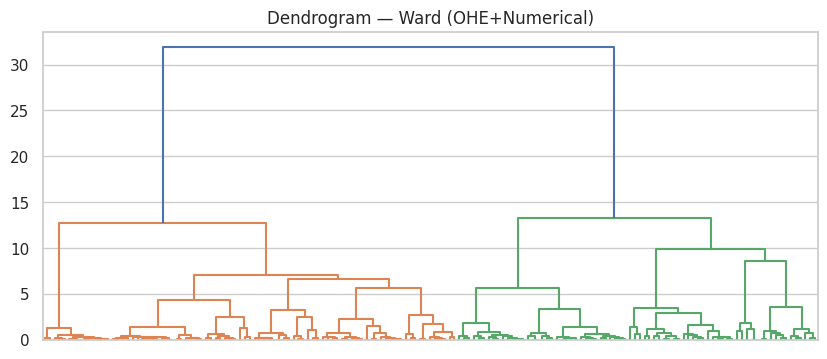

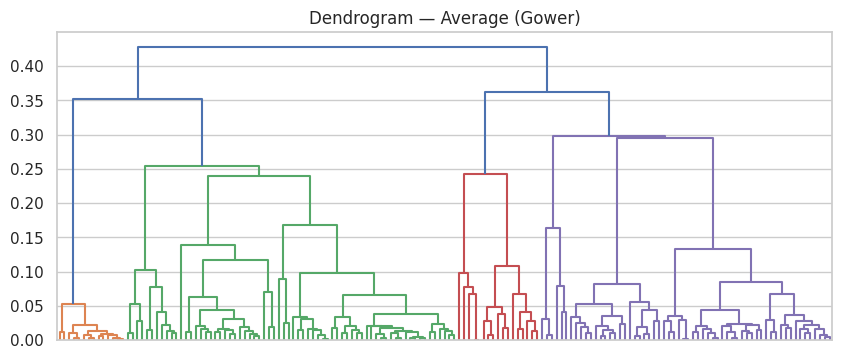

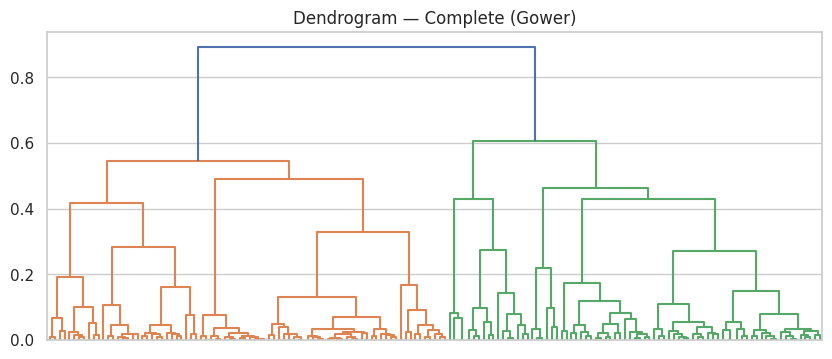

In [8]:
# Ward (OHE + numerical)
Z_ward = linkage(X_full, method='ward')
plt.figure(figsize=(10,4)); dendrogram(Z_ward, no_labels=True); plt.title('Dendrogram — Ward (OHE+Numerical)'); plt.show()
labels_ward = fcluster(Z_ward, t=best_k, criterion='maxclust') - 1

# Gower distance
D_gower = compute_gower_matrix(df, cat_cols, num_cols)
# Average (Gower)
Z_avg = linkage(squareform(D_gower, checks=False), method='average')
plt.figure(figsize=(10,4)); dendrogram(Z_avg, no_labels=True); plt.title('Dendrogram — Average (Gower)'); plt.show()
labels_avg = fcluster(Z_avg, t=best_k, criterion='maxclust') - 1
# Complete (Gower)
Z_cmpl = linkage(squareform(D_gower, checks=False), method='complete')
plt.figure(figsize=(10,4)); dendrogram(Z_cmpl, no_labels=True); plt.title('Dendrogram — Complete (Gower)'); plt.show()
labels_cmpl = fcluster(Z_cmpl, t=best_k, criterion='maxclust') - 1


## 1.3 DBSCAN (Gower) ve HDBSCAN

In [9]:
# DBSCAN (Gower, precomputed) — eps
eps_grid = np.linspace(0.1, 0.6, 11)
best_db = None; best_score = -1; labels_db = None; best_eps=None
for eps in eps_grid:
    db = DBSCAN(eps=eps, min_samples=5, metric='precomputed')
    labs = db.fit_predict(D_gower)
    S = set(labs)
    if len(S) <= 1 or (len(S)==2 and -1 in S):
        continue
    mask = labs != -1
    if mask.sum()<2 or len(set(labs[mask]))<2: continue
    sil = silhouette_score(D_gower[np.ix_(mask,mask)], labs[mask], metric='precomputed')
    if sil>best_score: best_score=sil; best_db=db; labels_db=labs; best_eps=eps

if labels_db is None:
    labels_db = np.full(D_gower.shape[0], -1)
else:
    print(f'the best DBSCAN: eps={best_eps:.2f}, silhouette={best_score:.3f}')

# HDBSCAN (Euclidean, X_full)
if hdbscan is not None:
    hdb = hdbscan.HDBSCAN(min_cluster_size=5, metric='euclidean')
    labels_hdb = hdb.fit_predict(X_full)
else:
    print('Warn: no any hdbscan package')
    labels_hdb = np.full(X_full.shape[0], -1)


the best DBSCAN: eps=0.10, silhouette=0.589


## 1.4 İç/Dış Metrikler ve Çapraz Tablolar (Tam Özellik Uzayı)

In [10]:
from collections import OrderedDict

def medoid_index(D, idxs):
    if len(idxs)==0: return None
    sub = D[np.ix_(idxs, idxs)]
    return idxs[int(np.argmin(sub.sum(axis=1)))]

def davies_bouldin_general(D, labels):
    uniq = [c for c in np.unique(labels) if c!=-1]
    if len(uniq)<2: return np.nan
    clusters = {c: np.where(labels==c)[0].tolist() for c in uniq}
    S, M = {}, {}
    for c, idxs in clusters.items():
        m = medoid_index(D, idxs); M[c]=m
        S[c] = D[np.ix_(idxs,[m])].mean() if m is not None else 0.0
    R=[]
    for i in uniq:
        vals=[]
        for j in uniq:
            if i==j: continue
            denom = D[M[i], M[j]] if (M[i] is not None and M[j] is not None) else 0.0
            if denom==0: continue
            vals.append((S[i]+S[j])/denom)
        if vals: R.append(max(vals))
    return float(np.mean(R)) if R else np.nan

def evaluate(name, labels, X_vec=None, D=None):
    res=OrderedDict()
    # Silhouette
    try:
        if D is not None:
            m = labels!=-1
            res['silhouette'] = silhouette_score(D[np.ix_(m,m)], labels[m], metric='precomputed') if m.sum()>1 and len(set(labels[m]))>1 else np.nan
        elif X_vec is not None:
            res['silhouette'] = silhouette_score(X_vec, labels)
        else:
            res['silhouette'] = np.nan
    except Exception:
        res['silhouette'] = np.nan
    # DBI
    try:
        if D is not None:
            res['davies_bouldin'] = davies_bouldin_general(D, labels)
        elif X_vec is not None:
            res['davies_bouldin'] = davies_bouldin_score(X_vec, labels)
        else:
            res['davies_bouldin'] = np.nan
    except Exception:
        res['davies_bouldin'] = np.nan
    # CH
    try:
        res['calinski_harabasz'] = calinski_harabasz_score(X_vec, labels) if (X_vec is not None and len(set(labels))>1) else np.nan
    except Exception:
        res['calinski_harabasz'] = np.nan
    return name, res

results = []
results.append(evaluate('kPrototypes', labels_kp, D=compute_gower_matrix(df, cat_cols, num_cols)))
results.append(evaluate('Hierarchical_Ward', labels_ward, X_vec=X_full))
results.append(evaluate('Hierarchical_Average_Gower', labels_avg, D=D_gower))
results.append(evaluate('Hierarchical_Complete_Gower', labels_cmpl, D=D_gower))
results.append(evaluate('DBSCAN_Gower', labels_db, D=D_gower))
results.append(evaluate('HDBSCAN', labels_hdb, X_vec=X_full))
metrics_full = pd.DataFrame([{**{'method':k}, **v} for k,v in results]).set_index('method')
display(metrics_full)

# Dış metrikler ve çapraz tablolar
def ext_metrics(labels, name):
    m = labels!=-1
    if m.sum()==len(labels):
        return name, adjusted_rand_score(y_cls, labels), normalized_mutual_info_score(y_cls, labels), fowlkes_mallows_score(y_cls, labels)
    elif m.sum()>=2 and len(set(labels[m]))>1:
        return name, adjusted_rand_score(y_cls[m], labels[m]), normalized_mutual_info_score(y_cls[m], labels[m]), fowlkes_mallows_score(y_cls[m], labels[m])
    return name, np.nan, np.nan, np.nan

ext_rows = []
for (lab, nm) in [(labels_kp,'kPrototypes'),(labels_ward,'Hierarchical_Ward'),(labels_avg,'Hierarchical_Average_Gower'),(labels_cmpl,'Hierarchical_Complete_Gower'),(labels_db,'DBSCAN_Gower'),(labels_hdb,'HDBSCAN')]:
    ext_rows.append(ext_metrics(lab, nm))
metrics_ext_full = pd.DataFrame(ext_rows, columns=['method','ARI','NMI','FMI']).set_index('method')
display(metrics_ext_full)

def cross_tab(labels, name):
    print(name)
    return pd.crosstab(pd.Series(labels, name='cluster'), pd.Series(y_cls, name='class'))
display(cross_tab(labels_kp,'kPrototypes'), cross_tab(labels_ward,'Hierarchical_Ward'), cross_tab(labels_avg,'Hierarchical_Average_Gower'), cross_tab(labels_cmpl,'Hierarchical_Complete_Gower'), cross_tab(labels_db,'DBSCAN_Gower'), cross_tab(labels_hdb,'HDBSCAN'))


,silhouette,davies_bouldin,calinski_harabasz
method,,,
kPrototypes,0.267172,1.503132,NaN
Hierarchical_Ward,0.490773,0.613579,151.456250
Hierarchical_Average_Gower,0.552705,0.596268,NaN
Hierarchical_Complete_Gower,0.517686,0.726472,NaN
DBSCAN_Gower,0.588768,0.648952,NaN
HDBSCAN,0.481472,1.744974,72.394751


,ARI,NMI,FMI
method,,,
kPrototypes,0.324041,0.467677,0.570342
Hierarchical_Ward,0.383510,0.446064,0.628677
Hierarchical_Average_Gower,0.373170,0.427783,0.618518
Hierarchical_Complete_Gower,0.359125,0.412635,0.601682
DBSCAN_Gower,0.158818,0.273477,0.452265
HDBSCAN,0.267661,0.397001,0.519221


kPrototypes
Hierarchical_Ward
Hierarchical_Average_Gower
Hierarchical_Complete_Gower
DBSCAN_Gower
HDBSCAN


class,1,2
cluster,,
0,38,0
1,0,5
2,19,9
3,0,27
4,1,39
5,21,0


class,1,2
cluster,,
0,14,0
1,63,8
2,1,34
3,0,22
4,0,5
5,1,11


class,1,2
cluster,,
0,14,0
1,61,7
2,1,16
3,2,4
4,0,19
5,1,34


class,1,2
cluster,,
0,27,4
1,14,0
2,34,3
3,1,16
4,2,4
5,1,53


class,1,2
cluster,,
-1,2,4
0,1,34
1,18,2
2,9,2
3,34,22
4,1,16
5,14,0


class,1,2
cluster,,
-1,4,9
0,1,12
1,9,2
2,1,34
3,14,0
4,18,1
5,32,3
6,0,19


## 2. Boyut Azaltma — FAMD ile azalt, **PCA/t‑SNE** ile görselleştir (yalnızca sayısal bileşenler)

In [13]:
# FAMD: fit for mixed dataset; Result components are **numerical**
assert prince is not None, 'no prince package'
#First, fit with the maximum number of components (as many as the number of features)
max_comp = len(cat_cols + num_cols)
famd_full = prince.FAMD(n_components=max_comp, random_state=42)
famd_full = famd_full.fit(df[cat_cols + num_cols])

# Use eigenvalues_ to calculate explained variance ratio
expl = np.array(famd_full.eigenvalues_) / famd_full.eigenvalues_.sum()
cum = np.cumsum(expl)
k85 = int(np.searchsorted(cum, 0.85) + 1)
print('FAMD  inertia:', np.round(expl,4))
print('FAMD cumulative  inertia:', np.round(cum,4))
print(f'Number of components selected for above 85%: {k85} (cumulative={cum[k85-1]:.3f})')

# Refit-transform with selected k85
famd = prince.FAMD(n_components=k85, random_state=42).fit(df[cat_cols + num_cols])
Z = famd.transform(df[cat_cols + num_cols]).values  # (n x k85), completely numerical
Z.shape

FAMD  inertia: [0.6029 0.1284 0.0751 0.0646 0.0645 0.0645]
FAMD cumulative  inertia: [0.6029 0.7312 0.8063 0.8709 0.9355 1.    ]
Number of components selected for above 85%: 4 (cumulative=0.871)


(159, 4)

## 3. Azaltılmış Uzayda Kümeleme (k‑Means, Ward, DBSCAN, HDBSCAN) + PCA/t‑SNE Görselleri ve Metrikler

In [14]:
# kMeans (azaltılmış) — adil kıyas için k = best_k
km_red = KMeans(n_clusters=best_k, random_state=42, n_init=20).fit_predict(Z)
# Ward (azaltılmış)
ward_red = AgglomerativeClustering(n_clusters=best_k, linkage='ward').fit_predict(Z)
# DBSCAN (azaltılmış, Euclidean)
db_red = DBSCAN(eps=0.5, min_samples=5).fit_predict(Z)
# HDBSCAN (azaltılmış)
if hdbscan is not None:
    hdb_red = hdbscan.HDBSCAN(min_cluster_size=5, metric='euclidean').fit_predict(Z)
else:
    hdb_red = np.full(Z.shape[0], -1)

# PCA (2B/3B) — via Z
p2 = PCA(n_components=2, random_state=42).fit_transform(Z)
p3 = PCA(n_components=3, random_state=42).fit_transform(Z)
def plot_scatter_2d(X2, labels, title):
    tmp = pd.DataFrame(X2, columns=['PC1','PC2']); tmp['cluster']=labels.astype(str)
    px.scatter(tmp, x='PC1', y='PC2', color='cluster', title=title).show()
def plot_scatter_3d(X3, labels, title):
    tmp = pd.DataFrame(X3, columns=['PC1','PC2','PC3']); tmp['cluster']=labels.astype(str)
    px.scatter_3d(tmp, x='PC1', y='PC2', z='PC3', color='cluster', title=title).show()

plot_scatter_2d(p2, km_red, 'Reduced Space — kMeans (PCA 2B)')
plot_scatter_3d(p3, km_red, 'Reduced Space — kMeans (PCA 3B)')
plot_scatter_2d(p2, ward_red, 'Reduced Space — Ward (PCA 2B)')
plot_scatter_2d(p2, db_red, 'Reduced Space — DBSCAN (PCA 2B)')
plot_scatter_2d(p2, hdb_red, 'Reduced Space — HDBSCAN (PCA 2B)')

# t-SNE (2B/3B) — via Z
ts2 = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42).fit_transform(Z)
ts3 = TSNE(n_components=3, perplexity=30, n_iter=1000, random_state=42).fit_transform(Z)
plot_scatter_2d(ts2, km_red, 'Reduced Space — kMeans (t-SNE 2B)')
plot_scatter_2d(ts2, ward_red, 'Reduced Space — Ward (t-SNE 2B)')
plot_scatter_2d(ts2, db_red, 'Reduced Space— DBSCAN (t-SNE 2B)')
plot_scatter_2d(ts2, hdb_red, 'Reduced Space — HDBSCAN (t-SNE 2B)')

# internal metrics (Euclidean, Z)
def eval_internal_Z(name, labels, Z):
    res = {}
    try:
        res['silhouette'] = silhouette_score(Z, labels) if len(set(labels))>1 else np.nan
    except Exception:
        res['silhouette'] = np.nan
    try:
        res['davies_bouldin'] = davies_bouldin_score(Z, labels) if len(set(labels))>1 else np.nan
    except Exception:
        res['davies_bouldin'] = np.nan
    try:
        res['calinski_harabasz'] = calinski_harabasz_score(Z, labels) if len(set(labels))>1 else np.nan
    except Exception:
        res['calinski_harabasz'] = np.nan
    return {'method':name, **res}

metrics_red = pd.DataFrame([
    eval_internal_Z('kMeans_reduced', km_red, Z),
    eval_internal_Z('Ward_reduced', ward_red, Z),
    eval_internal_Z('DBSCAN_reduced', db_red, Z),
    eval_internal_Z('HDBSCAN_reduced', hdb_red, Z)
]).set_index('method')
display(metrics_red)


,silhouette,davies_bouldin,calinski_harabasz
method,,,
kMeans_reduced,0.536620,0.701634,172.425389
Ward_reduced,0.534137,0.686905,166.783840
DBSCAN_reduced,0.504063,1.513223,51.710638
HDBSCAN_reduced,0.573071,1.586275,108.777496


## 3.2 Önce–Sonra Kıyas (Aynı aile yöntemleri) — etiket örtüşmesi & ARI

In [15]:
def label_agreement(y1, y2):
    C = contingency_matrix(y1, y2)
    return np.sum(np.max(C, axis=0)) / np.sum(C)

pairs = []
# kPrototypes (before)','kMeans (after)
pairs.append(('kPrototypes (before)','kMeans (after)', labels_kp, km_red))
# Ward (before)','Ward (after)
pairs.append(('Ward (before)','Ward (after)', labels_ward, ward_red))
# DBSCAN (before)','DBSCAN (after)
pairs.append(('DBSCAN (before)','DBSCAN (after)', labels_db, db_red))
#HDBSCAN (before)','HDBSCAN (after)
pairs.append(('HDBSCAN (before)','HDBSCAN (after)', labels_hdb, hdb_red))

rows=[]
for n1,n2,l1,l2 in pairs:
    # Exclude noise labels (-1)
    m = (l1!=-1) & (l2!=-1)
    if m.sum()>0 and len(set(l1[m]))>1 and len(set(l2[m]))>1:
        agree = label_agreement(l1[m], l2[m])
        ari = adjusted_rand_score(l1[m], l2[m])
    else:
        agree = np.nan; ari=np.nan
    rows.append({'pair':f'{n1} ↔ {n2}','label_agreement':agree,'ARI_between_labels':ari})
cmp_df = pd.DataFrame(rows)
display(cmp_df)

,pair,label_agreement,ARI_between_labels
0,kPrototypes (before) ↔ kMeans (after),0.660377,0.405187
1,Ward (before) ↔ Ward (after),0.968553,0.744966
2,DBSCAN (before) ↔ DBSCAN (after),1.000000,0.780044
3,HDBSCAN (before) ↔ HDBSCAN (after),1.000000,1.000000


---
## 4. Yorum ve Sonuç
- **FAMD bileşen sayısı** ve kümülatif inertia raporlandı; %85 üzeri eşiğe göre `k85` seçildi.
- Azaltılmış uzayda **k‑Means/ Ward/ DBSCAN/ HDBSCAN** çalıştırıldı; **PCA (2B/3B)** ve **t‑SNE (2B/3B)** ile görseller üretildi.
- **İç metrikler** (Silhouette, DB, CH) tam uzay vs. azaltılmış uzay karşılaştırıldı.
- Aile içi **önce–sonra** kıyasları (kPrototypes→kMeans, Ward→Ward, DBSCAN→DBSCAN, HDBSCAN→HDBSCAN) için **etiket örtüşmesi** ve **ARI** verildi.
- Sunumda: Elbow/Cost, dendrogramlar, PCA/t‑SNE görselleri, metrik tabloları ve yukarıdaki kıyas tablosunu kullan.
